### Tangentially active polymer


### 0. Imports & environment

In [8]:
# --- imports & environment ---
import sys
import pathlib
import json

import numpy as np
import scipy.stats
import torch
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd


plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent, _cwd.parent.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break

from eesi.systems.tap.data import (
    REF_DATA_PATH, load_ref_data, sample_prior, log_prior, prior_entropy,
    bond_vectors, bond_cosines, bond_moments,
    end_to_end_sq, end_to_end_mean_sq, gyration_sq, solve_cos_theta_0, dof,
    rouse_mode_moments
)

from eesi.systems.tap.ot import tap_ot_couple
from eesi.ot import transport_cost
from eesi import CHECKPOINTS_DIR, DATA_DIR

torch.set_default_dtype(torch.float64)   # the train hooks default to float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### 0.1. Some useful functions

In [9]:
N       = 20        # monomers
DOF     = dof(N)    # 3 (N-1) = 57


def bond_lengths(x):                     # (B,N,3) -> (B*(N-1),)
    return bond_vectors(x).norm(dim=-1).reshape(-1).cpu().numpy()

# <u_i . u_{i+k}> for unit bond tangents
def tangent_correlation(x):
    u = bond_vectors(x)
    u = u / u.norm(dim=-1, keepdim=True)
    nb = u.shape[1]
    return np.array([(u[:, :nb-k] * u[:, k:]).sum(-1).mean().item() for k in range(nb)])

def smooth(v, k=10):
    v = np.asarray(v)
    return np.convolve(v, np.ones(k) / k, mode="valid") if len(v) >= k else v

# avoid OOMs if possible
@torch.no_grad()
def chunked(fn, x0, size=500):
    return torch.cat([fn(c) for c in x0.split(size)])

### 1. Datasets & samplers

The base distribution is a semiflexible chain: $N-1$ bonds whose magnitudes follow a
harmonic spring of stiffness $k$ about a finite equilibrium length $b$, with successive bonds
coupled by a bending potential $\gamma(\cos\theta - \cos\theta_0)^2$. 

**Calibration.** Two of the parameters are taken from the exact energy function of the reference data
($k = 100$, $b = 1$),while the angle bend constant is inferred from the data $\gamma = 1/(2\,\mathrm{var}(\cos\theta))$ 
and $\cos\theta_0$, is fitted so the prior's $\mathbb{E}[R_e^2]$ matches the data's.


In [10]:
# --- target: the reference TAP configurations ---
n_data = 1_000_000
x1 = load_ref_data(REF_DATA_PATH, n=n_data, n_particles=N).to(device)

print("target dataset:", tuple(x1.shape))
print(f"E[Re^2] = {end_to_end_sq(x1).mean():.4f}   E[Rg^2] = {gyration_sq(x1).mean():.4f}"
      f"   Re^2/Rg^2 = {(end_to_end_sq(x1).mean()/gyration_sq(x1).mean()):.4f}")

target dataset: (1000000, 20, 3)
E[Re^2] = 44.3005   E[Rg^2] = 6.8505   Re^2/Rg^2 = 6.4667


In [11]:
# --- calibrate the prior from the data, then check it ---

_q   = bond_vectors(x1).norm(dim=-1)
_cos = bond_cosines(x1)

K_BOND   = 100.0              # harmonic bond stiffness
B_BOND   = 1.0                   # equilibrium bond length
GAMMA_BEND = 1.0 / (2.0 * _cos.var().item())  # bending constant
COS_THETA_0 = solve_cos_theta_0(              # fitted so E[Re^2] matches the data
    K_BOND, B_BOND, GAMMA_BEND, end_to_end_sq(x1).mean().item(), N)

print(f"k = {K_BOND:.4f}   b = {B_BOND:.4f}   gamma = {GAMMA_BEND:.4f}   "
      f"cos_theta_0 = {COS_THETA_0:.4f}")


x0_check = sample_prior(1_000_000, K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0, n_particles=N)
print(f"\n{'':<12}{'E[Re^2]':>10}{'E[Rg^2]':>10}{'E[|b|^2]':>10}")
print(f"{'prior':<12}{end_to_end_sq(x0_check).mean():10.4f}{gyration_sq(x0_check).mean():10.4f}"
      f"{(bond_vectors(x0_check)**2).sum(-1).mean():10.4f}")
print(f"{'data':<12}{end_to_end_sq(x1).mean():10.4f}{gyration_sq(x1).mean():10.4f}"
      f"{(bond_vectors(x1)**2).sum(-1).mean():10.4f}")
print(f"{'analytic':<12}{end_to_end_mean_sq(K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0, N):10.4f}"
      f"{'':>10}{bond_moments(K_BOND, B_BOND)[2]:10.4f}")

# The analytic entropy of the prior and the average log density
S_prior = prior_entropy(K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0, N)
_mc = -log_prior(x0_check, K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0).mean()
print(f"\nS[p0] (analytic) = {S_prior:+.4f} nats     -E[log p0] = {_mc:+.4f}")
del x0_check

k = 100.0000   b = 1.0000   gamma = 2.3327   cos_theta_0 = 0.5348

               E[Re^2]   E[Rg^2]  E[|b|^2]
prior          44.3143    7.1199    1.0498
data           44.3005    6.8505    1.0598
analytic       44.3005              1.0498

S[p0] (analytic) = +25.1414 nats     -E[log p0] = +25.1447


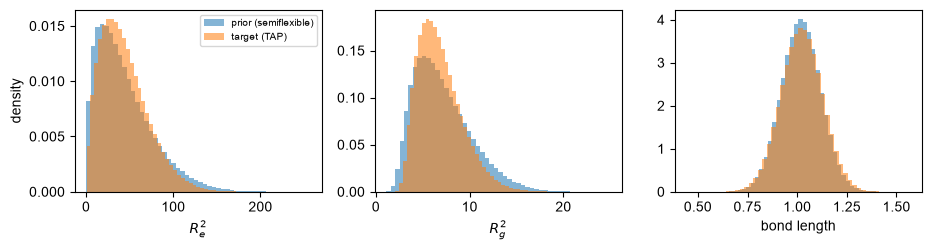

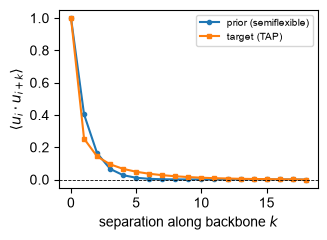

In [12]:
# --- prior vs target structural features
x0_ref = sample_prior(1_000_000, K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0,
                      n_particles=N, device=device)

fig, ax = plt.subplots(1, 3, figsize=(9.5, 2.6))
for a, (v0, v1, lab) in zip(ax, [
    (end_to_end_sq(x0_ref).cpu(), end_to_end_sq(x1).cpu(), r"$R_e^2$"),
    (gyration_sq(x0_ref).cpu(),   gyration_sq(x1).cpu(),   r"$R_g^2$"),
    (bond_lengths(x0_ref),        bond_lengths(x1),        "bond length"),
]):
    a.hist(np.asarray(v0), bins=50, density=True, alpha=0.55, label="prior (semiflexible)")
    a.hist(np.asarray(v1), bins=50, density=True, alpha=0.55, label="target (TAP)")
    a.set_xlabel(lab)
ax[0].set_ylabel("density"); ax[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

fig, a = plt.subplots(figsize=(3.375, 2.5))
a.plot(tangent_correlation(x0_ref), 'o-', ms=3, label="prior (semiflexible)")
a.plot(tangent_correlation(x1), 's-', ms=3, label="target (TAP)")
a.axhline(0, c="k", lw=0.6, ls="--")
a.set_xlabel("separation along backbone $k$"); a.set_ylabel(r"$\langle u_i \cdot u_{i+k}\rangle$")
a.legend(fontsize=7); plt.tight_layout(); plt.show()

#### 1.1 The ideal system

The thermodynamic integration that is carried out for $\mathrm{Pe} = 0$ is done with no angle bending potential, so there is an additional entropy difference. This is calculated directly here, which we refer to as the "ideal" polymer system.

In [13]:
# --- get entropy of the ideal chain used in thermodynamic integration ---


K_BOND_ID   = 100.0              # harmonic bond stiffness
B_BOND_ID   = 1.0                   # equilibrium bond length
GAMMA_BEND_ID = 0.0
COS_THETA_0_ID = 0.0

x0_check_id = sample_prior(1_000_000, K_BOND_ID, B_BOND_ID, GAMMA_BEND_ID, COS_THETA_0_ID, n_particles=N)
print(f"\n{'':<12}{'E[Re^2]':>10}{'E[Rg^2]':>10}{'E[|b|^2]':>10}")
print(f"{'ideal':<12}{end_to_end_sq(x0_check_id).mean():10.4f}{gyration_sq(x0_check_id).mean():10.4f}"
      f"{(bond_vectors(x0_check_id)**2).sum(-1).mean():10.4f}")
print(f"{'data':<12}{end_to_end_sq(x1).mean():10.4f}{gyration_sq(x1).mean():10.4f}"
      f"{(bond_vectors(x1)**2).sum(-1).mean():10.4f}")
print(f"{'analytic':<12}{end_to_end_mean_sq(K_BOND_ID, B_BOND_ID, GAMMA_BEND_ID, COS_THETA_0_ID, N):10.4f}"
      f"{'':>10}{bond_moments(K_BOND_ID, B_BOND_ID)[2]:10.4f}")

# The analytic entropy of the prior and the average log density
S_ideal = prior_entropy(K_BOND_ID, B_BOND_ID, GAMMA_BEND_ID, COS_THETA_0_ID, N)
_mc = -log_prior(x0_check_id, K_BOND_ID, B_BOND_ID, GAMMA_BEND_ID, COS_THETA_0_ID).mean()
print(f"\nS[p_id] (analytic) = {S_ideal:+.4f} nats     -E[log p_id] = {_mc:+.4f}")
del x0_check_id

dS_pi = S_prior-S_ideal
print(f"\n\nS[p0] - S[p_id] (analytic) = {dS_pi:+.4f}")


               E[Re^2]   E[Rg^2]  E[|b|^2]
ideal          19.9468    3.4907    1.0499
data           44.3005    6.8505    1.0598
analytic       19.9462              1.0498

S[p_id] (analytic) = +31.6774 nats     -E[log p_id] = +31.6820


S[p0] - S[p_id] (analytic) = -6.5359


### 2. Optimal Transport

`tap_ot_couple` optimizes over O(3) and the batch assignment. Because the system 
is no longer equivariant under particle permutations, we are able to minimize over the 
whole symmetry group exactly, LJ system.

In [14]:
batch_size = 256
torch.manual_seed(9448)

idx = torch.randint(0, x1.shape[0], (batch_size,), device=device)
xb  = x1[idx]
xa  = sample_prior(batch_size, K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0,
                   n_particles=N, device=device)

cells_2x2 = {}
for align in (True, False):
    for batch in (True, False):
        a, b = tap_ot_couple(xa, xb, align=align, batch=batch)
        cells_2x2[(align, batch)] = transport_cost(a, b).item()

base = cells_2x2[(False, False)]
print(f"{'align':>6} {'batch':>6} {'transport':>11} {'vs random':>10}")
for (al, ba), c in cells_2x2.items():
    print(f"{str(al):>6} {str(ba):>6} {c:11.4f} {100*(c/base-1):9.1f}%")


 align  batch   transport  vs random
  True   True     31.5195     -96.4%
  True  False    128.0381     -85.3%
 False   True    120.4803     -86.2%
 False  False    871.5300       0.0%


### 3. Training with equivariant OT

Training configurations and scripts are found in the `/configs/` sub-folder. Here we just plot the losses and on-the-fly entropy estimates. 

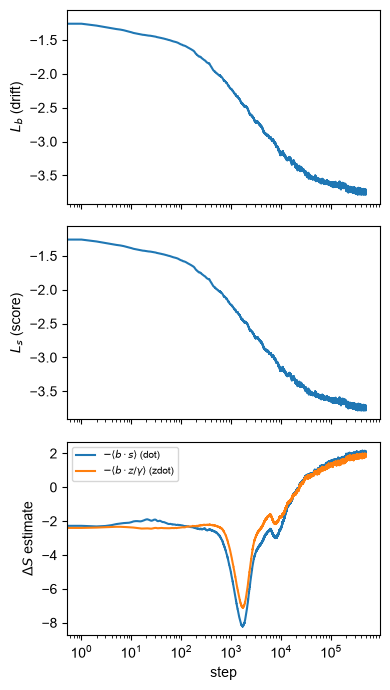

In [15]:
# training was split between two runs
df = pd.read_csv("results/Pe0_history.csv")


fig, ax = plt.subplots(3, 1, sharex=True, figsize=(4, 7))
ax[0].plot(smooth(df.loss_b,1000)); ax[0].set_ylabel(r"$L_b$ (drift)")
ax[1].plot(smooth(df.loss_b,1000));   ax[1].set_ylabel(r"$L_s$ (score)")
ax[2].plot(smooth(df.S_dot,1000),  label=r"$-\langle b\cdot s\rangle$ (dot)")
ax[2].plot(smooth(df.S_zdot,1000), label=r"$-\langle b\cdot z/\gamma\rangle$ (zdot)")
ax[2].set_ylabel(r"$\Delta S$ estimate"); ax[2].legend(fontsize=7)
ax[2].set_xlabel("step")
ax[2].set_xscale('log')
plt.tight_layout(); plt.show()

### 4. Sampling

In [18]:
torch.manual_seed(4)

x0 = sample_prior(100_000, K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0,
                  n_particles=N, device=device)

# previously-generated samples
x_gen = np.load(DATA_DIR / "tap_Pe0_gen.npy")
x_gen = torch.tensor(x_gen)

print(f"generated {tuple(x_gen.shape)}")
print(f"{'':<10}{'E[Re^2]':>10}{'E[Rg^2]':>10}{'E[cos]':>10}")
for name, s in [("prior", x0), ("generated", x_gen), ("reference", x1)]:
    print(f"{name:<10}{end_to_end_sq(s).mean():10.3f}{gyration_sq(s).mean():10.3f}"
          f"{bond_cosines(s).mean():10.3f}")

generated (10000, 20, 3)
             E[Re^2]   E[Rg^2]    E[cos]
prior         44.238     7.116     0.403
generated     43.949     6.812     0.252
reference     44.301     6.851     0.253


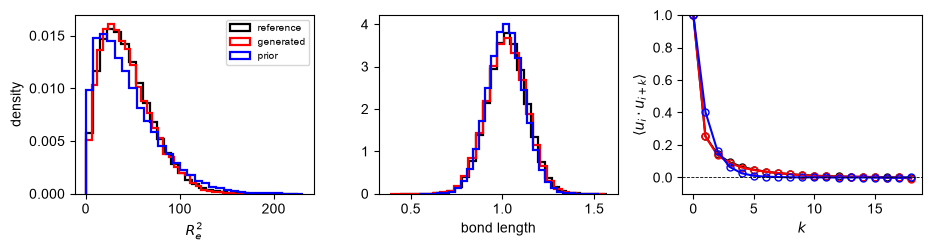

In [19]:
series = [(x1, "reference", "k"), (x_gen, "generated", "red") , 
          (x0,        "prior",     "blue")]

fig, ax = plt.subplots(1, 3, figsize=(9.5, 2.6))
for s, lab, c in series:
    ax[0].hist(end_to_end_sq(s).cpu().numpy(), bins=30, density=True,
               histtype="step", lw=1.6, color=c, label=lab)
    ax[1].hist(bond_lengths(s), bins=30, density=True,
               histtype="step", lw=1.6, color=c, label=lab)
    ax[2].plot(tangent_correlation(s), '-o',mfc='none',ms=5, c=c, label=lab)
ax[0].set_xlabel(r"$R_e^2$"); ax[1].set_xlabel("bond length")
ax[2].set_xlabel("$k$"); ax[2].set_ylabel(r"$\langle u_i \cdot u_{i+k}\rangle$")
ax[2].axhline(0, c="k", lw=0.6, ls="--")
ax[2].set_ylim(-0.1,1)
ax[0].set_ylabel("density"); ax[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

#### 4.1. Rouse modes

Rouse modes characterize structure and correlations at many length scales:

$$X_p = \sqrt{2/N}\sum_{j=1}^{N} R_j \cos\!\Big(\frac{\pi p (j - \tfrac12)}{N}\Big),
  \qquad k = 0 \ldots N-1.$$


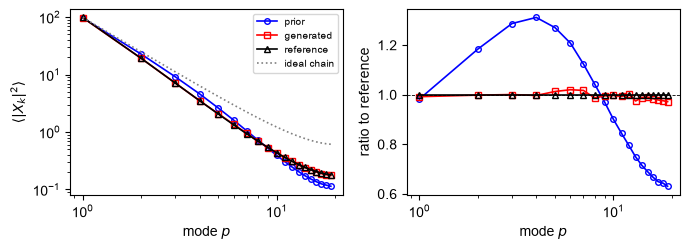

In [20]:
# --- Rouse modes: prior, generated, reference ---

rouse = {name: rouse_mode_moments(s)
         for name, s in [("prior", x0), ("generated", x_gen), ("reference", x1)]}
pp = np.arange(1, N)                      # k = 0 is the center of mass, not a mode

fig, ax = plt.subplots(1, 2, figsize=(7.0, 2.6))
for name, c, m in [("prior", "blue", "o"), ("generated", "red", "s"),
                   ("reference", "k", "^")]:
    msq = rouse[name][0].cpu().numpy()[1:]
    ax[0].plot(pp, msq, m + "-", mfc="none", ms=4, lw=1.2, c=c, label=name)
    ax[1].plot(pp, msq / rouse["reference"][0].cpu().numpy()[1:], m + "-",
               mfc="none", ms=4, lw=1.2, c=c)

# The ideal-chain shape, 1 / (4 sin^2(pi k / 2N)) ~ k^-2, matched to the data at k = 1.
# A guide to the eye only: this ensemble is tail-anchored and active, not a free
# Gaussian chain, so departures from it are physics rather than error.
ideal = 1.0 / (4.0 * np.sin(np.pi * pp / (2 * N)) ** 2)
ideal *= rouse["reference"][0].cpu().numpy()[1] / ideal[0]
ax[0].plot(pp, ideal, ls=":", lw=1.2, c="grey", label="ideal chain")

ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("mode $p$"); ax[0].set_ylabel(r"$\langle |X_k|^2 \rangle$")
ax[0].legend(fontsize=7)
ax[1].axhline(1.0, c="k", lw=0.6, ls="--")
ax[1].set_xscale("log")
ax[1].set_xlabel("mode $p$"); ax[1].set_ylabel(r"ratio to reference")
plt.tight_layout(); plt.show()


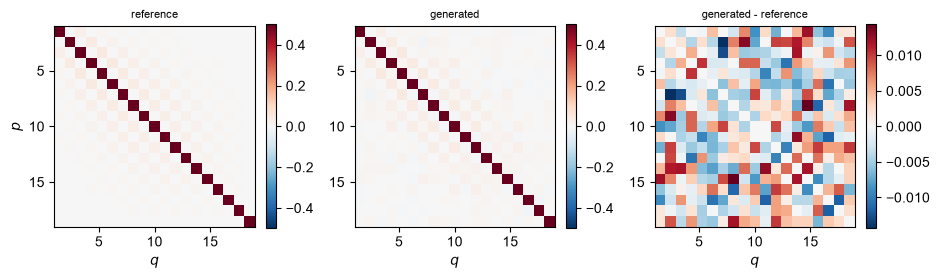

RMS off-diagonal difference : 0.0060
max |difference|            : 0.0144


In [21]:
# --- cross-mode correlations for an extra check ---
def corr(name):
    msq, cov = (t.cpu().numpy() for t in rouse[name])
    c = cov / np.sqrt(np.outer(msq, msq))
    return c[1:, 1:]

c_ref, c_gen = corr("reference"), corr("generated")
diff = c_gen - c_ref
ext = dict(extent=[1, N-1, N-1, 1])

fig, ax = plt.subplots(1, 3, figsize=(9.5, 2.9))
for a, (m, lab, vlim, cmap) in zip(ax, [
    (c_ref,  "reference",            0.5, "RdBu_r"),
    (c_gen,  "generated",            0.5, "RdBu_r"),
    (diff,   "generated - reference", np.abs(diff).max(), "RdBu_r"),
]):
    im = a.imshow(m, vmin=-vlim, vmax=vlim, cmap=cmap, **ext)
    a.set_title(lab, fontsize=8)
    a.set_xlabel("$q$")
    fig.colorbar(im, ax=a, fraction=0.046)
ax[0].set_ylabel("$p$")
plt.tight_layout(); plt.show()

off = ~np.eye(N-1, dtype=bool)
print(f"RMS off-diagonal difference : {np.sqrt((diff[off]**2).mean()):.4f}")
print(f"max |difference|            : {np.abs(diff[off]).max():.4f}")

### 5. Entropy estimates

Reading from previously-computed results.  See `/configs/` subdirectory for the scripts.

In [22]:
df = pd.read_csv("results/Pe0_entropy_batch.csv")

def boot(data):
    straps = scipy.stats.bootstrap((data,),np.mean,method='percentile')
    return 0.5*(straps.confidence_interval.high - straps.confidence_interval.low)

dS_TI = -4.607
print("Pe = 0 Entropy Estimates:")
print(f"TI (reference) : {dS_TI:+.3f} ± 0.01") # reference calculation
print(f"div(b)         : {np.mean(df['div'])+dS_pi:+.3f} ± {boot(df['div']):.2f}")
print(f"b*s            : {np.mean(df['dot'])+dS_pi:+.3f} ± {boot(df['dot']):.2f}")
print(f"b*z/gamma      : {np.mean(df['zdot'])+dS_pi:+.3f} ± {boot(df['zdot']):.2f}")



Pe = 0 Entropy Estimates:
TI (reference) : -4.607 ± 0.01
div(b)         : -4.657 ± 0.06
b*s            : -4.545 ± 0.07
b*z/gamma      : -4.780 ± 0.07


In [23]:
print("Pe = 0 Flow Estimates:")
print(f"TI (reference) : {dS_TI:+.3f} ± 0.01") # reference calculation
names = (('dot','b*s'),('div','div(b)'))
for name,label in names:
    with open(f"results/Pe0_entropy.json", "r") as f:
        summary = json.load(f)
        dS = summary['flow'][name]['dS']+dS_pi
        err = summary['flow'][name]['ci95']
        print(f"{label:<14} : {dS:+.3f} ± {err:.2f}")



Pe = 0 Flow Estimates:
TI (reference) : -4.607 ± 0.01
b*s            : -4.950 ± 0.09
div(b)         : -4.810 ± 0.07


### 6. Active Systems



In [24]:

names = ["Pe0", "Pe0p01", "Pe0p03","Pe0p1","Pe0p3",
            "Pe1","Pe3","Pe10","Pe30","Pe100"]
S_ideal = 31.6774
dS_Pe = []

for name in names:
    with open(f"results/{name}_entropy.json", "r") as f:
        summary = json.load(f)
    # note that this value already subtracts off the entropy of the prior
    # which is different for each Pe value. Therefore, we only need to 
    # subtract off the ideal entropy (no bending) to get the proper value
    dS_Pe.append(summary['batches']['zdot']['S_target'])

dS_Pe = np.array(dS_Pe) - S_ideal
Pe = np.array([0,0.01,0.03,0.1,0.3,1,3,10,30,100])
np.save("active_entropy.npy",np.transpose([Pe,dS_Pe]))


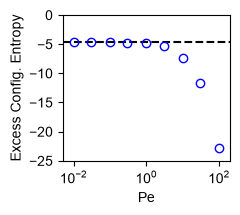

In [25]:
plt.figure(figsize=(2.5,2.25))
plt.hlines(dS_TI,5e-3,200,color='k',ls='--')
plt.plot(Pe,dS_Pe,'bo',mfc='none')
plt.xscale('log')
plt.xlabel('Pe')
plt.ylabel('Excess Config. Entropy')
plt.ylim(-25,0)
plt.xlim(5e-3,200)
plt.tight_layout()
plt.show()

